In [27]:
# Q1
import pandas as pd
import seaborn as sns

df = pd.read_csv("ford_car_dataset.csv")

print(df.head(10))
print("")
print(df.tail())
print("")
print(df.shape)
print("")
print(df.dtypes)


     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual    16700   Petrol  150  47.1 

In [28]:
# Q2
print(df.isnull().sum())
print("no of duplicate values")
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.shape)


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
no of duplicate values
154
(17812, 9)


In [29]:
# Q3
print(df.describe())
print(df["price"].min(), df["price"].max(), df["price"].mean(), df["price"].median())
print(df["mileage"].min(), df["mileage"].max(), df["mileage"].mean(), df["mileage"].median())
print(df["year"].min(), df["year"].max(), df["year"].mean(), df["year"].median())


               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  
495 54995 12269.556310352571 11288.0
1 177644 23381.146362003143 18277.0
1996 206

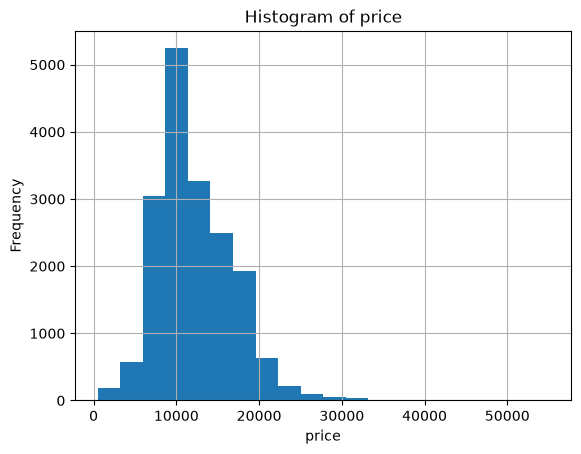

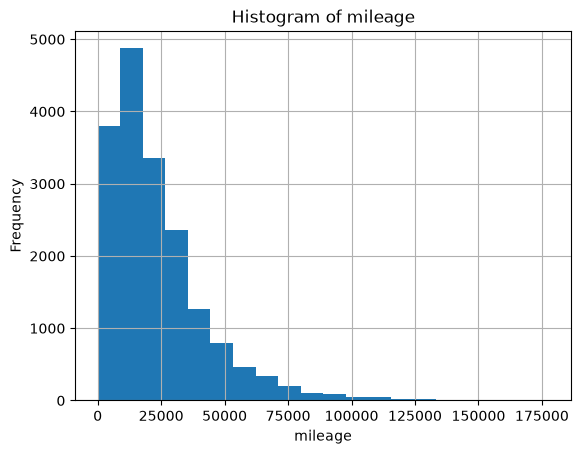

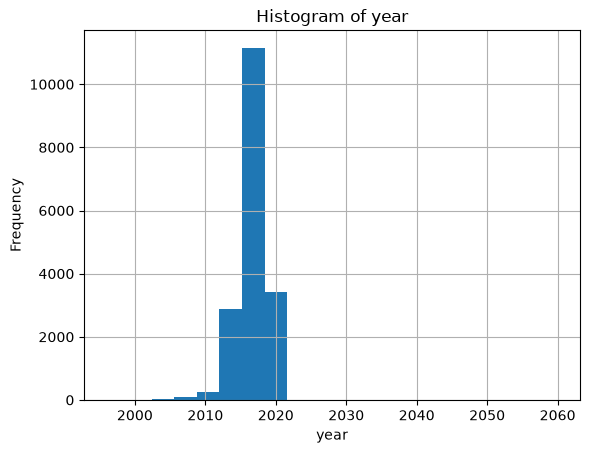

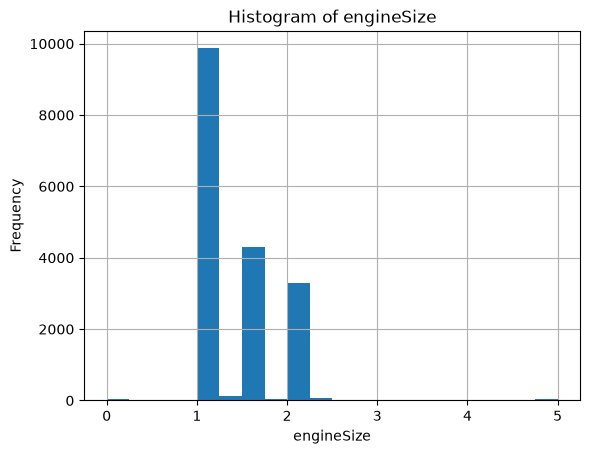

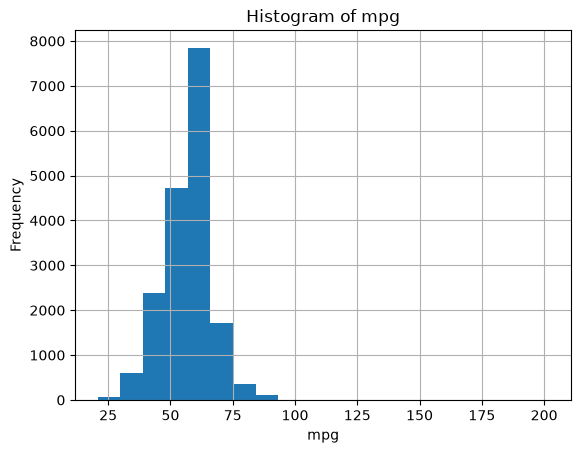

In [30]:
# Q4
import matplotlib.pyplot as plt

numeric_cols = ["price", "mileage", "year", "engineSize", "mpg"]

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=20)
    plt.title("Histogram of " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


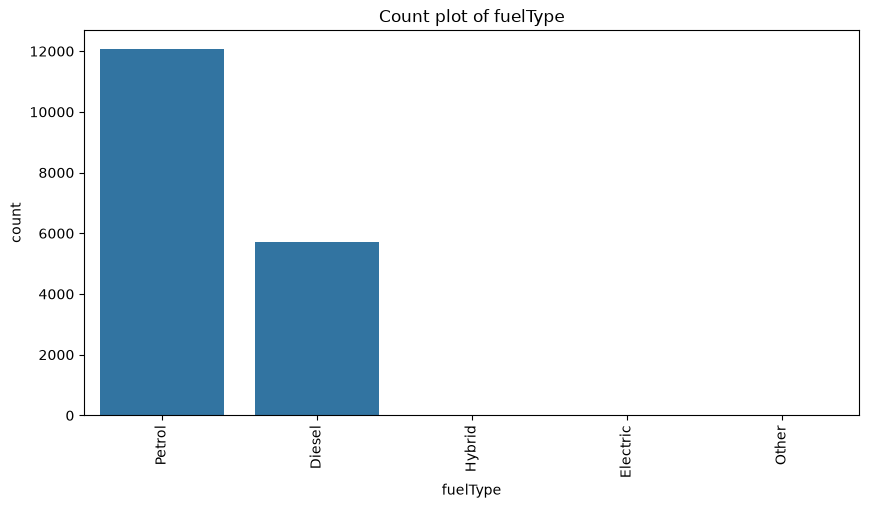

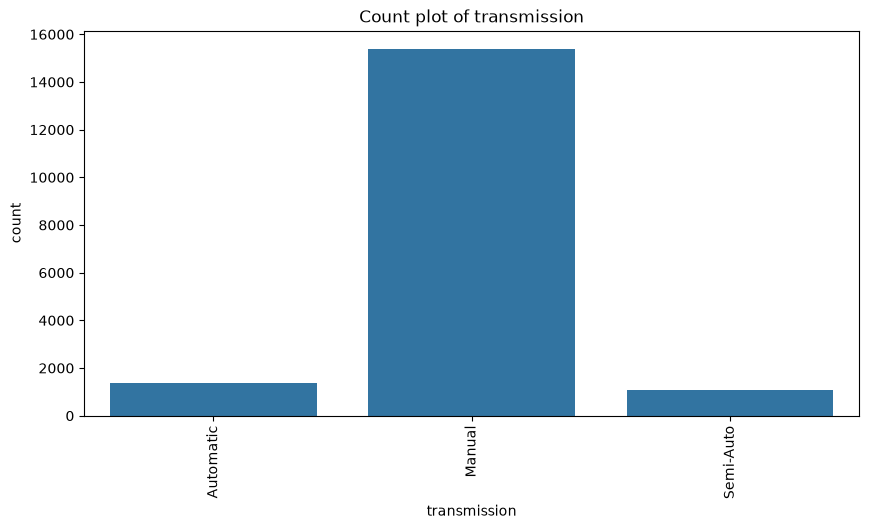

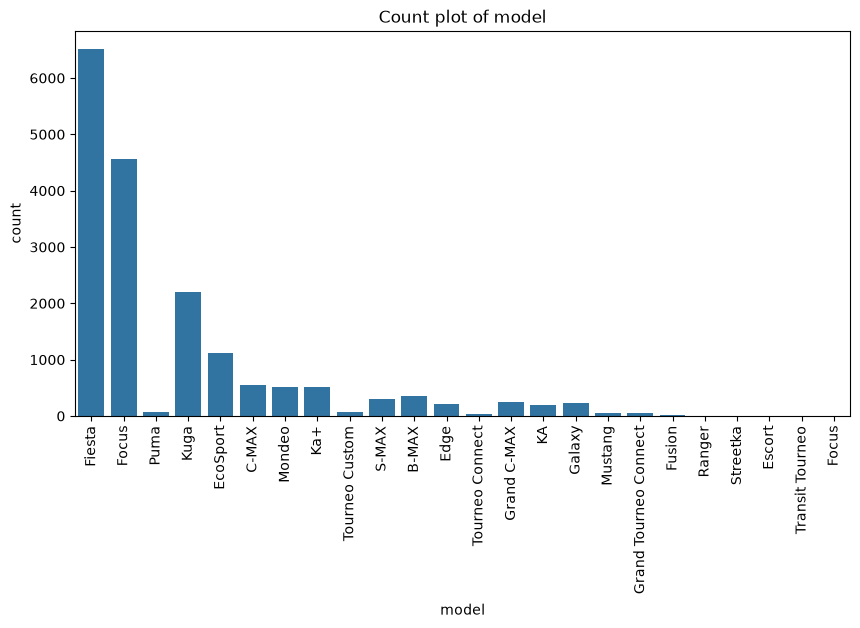

In [31]:
# Q5
categorical_cols = ["fuelType", "transmission", "model"]

for col in categorical_cols:
    plt.figure(figsize=(10,5))
    sns.countplot(x=col, data=df)
    plt.title("Count plot of " + col)
    plt.xticks(rotation=90)
    plt.show()


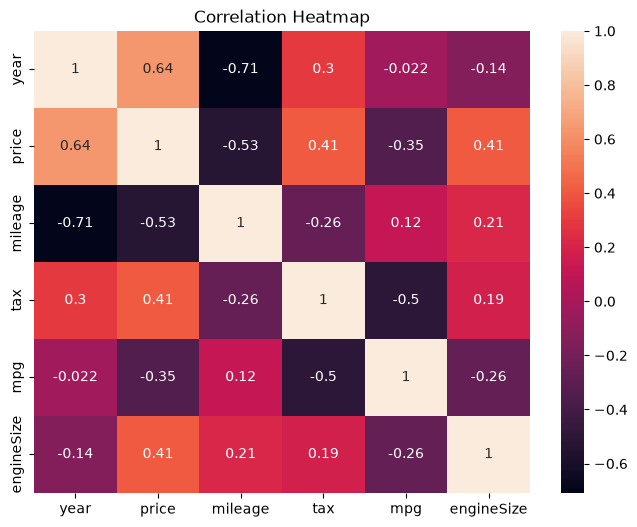

In [32]:
# Q6
numeric_df = df[["year", "price", "mileage", "tax", "mpg", "engineSize"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [33]:
# Q7
independent_features = ["model", "year", "transmission", "mileage", "fuelType", "tax", "mpg", "engineSize"]
dependent_feature = "price"

print(independent_features)
print(dependent_feature)


['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
price


In [34]:
# Q8
print(df[["transmission", "fuelType"]].head())

df_encoded = pd.get_dummies(df, columns=["model", "transmission", "fuelType"])

print(df_encoded.head())
print(df_encoded.shape)


  transmission fuelType
0    Automatic   Petrol
1       Manual   Petrol
2       Manual   Petrol
3       Manual   Petrol
4    Automatic   Petrol
   year  price  mileage  tax   mpg  engineSize  model_ B-MAX  model_ C-MAX  \
0  2017  12000    15944  150  57.7         1.0         False         False   
1  2018  14000     9083  150  57.7         1.0         False         False   
2  2017  13000    12456  150  57.7         1.0         False         False   
3  2019  17500    10460  145  40.3         1.5         False         False   
4  2019  16500     1482  145  48.7         1.0         False         False   

   model_ EcoSport  model_ Edge  ...  model_ Transit Tourneo  model_Focus  \
0            False        False  ...                   False        False   
1            False        False  ...                   False        False   
2            False        False  ...                   False        False   
3            False        False  ...                   False        False   
4 

In [35]:
# Q9
from sklearn.preprocessing import StandardScaler

numeric_features = ["year", "mileage", "tax", "mpg", "engineSize"]

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_encoded[numeric_features])

scaled_df = pd.DataFrame(scaled_values, columns=numeric_features)
print(scaled_df.head())


       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
154
(17812, 9)


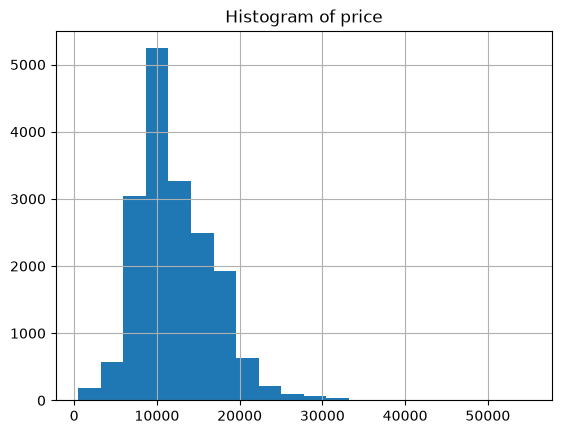

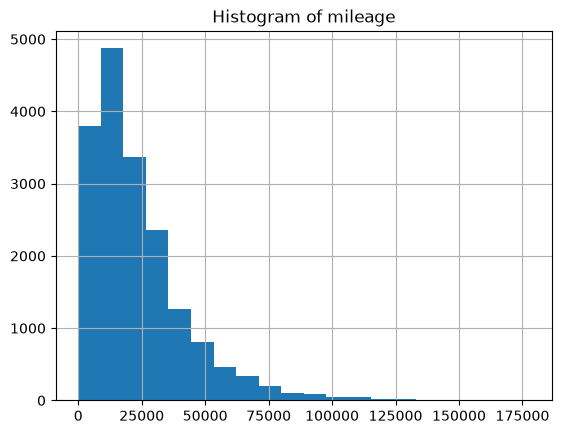

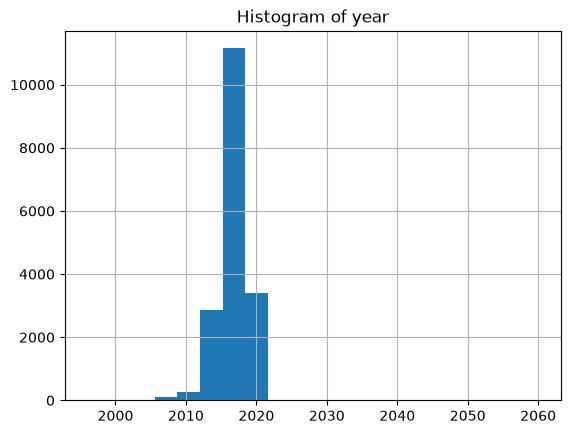

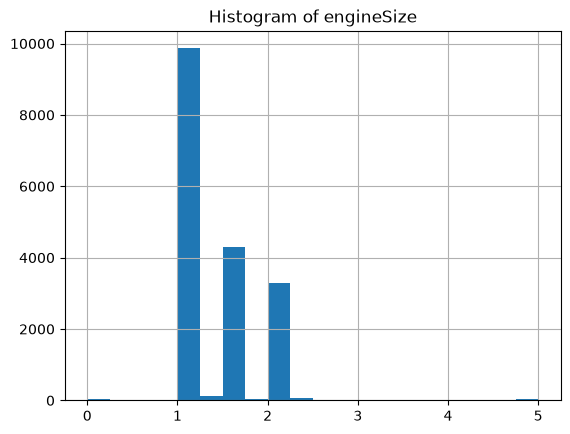

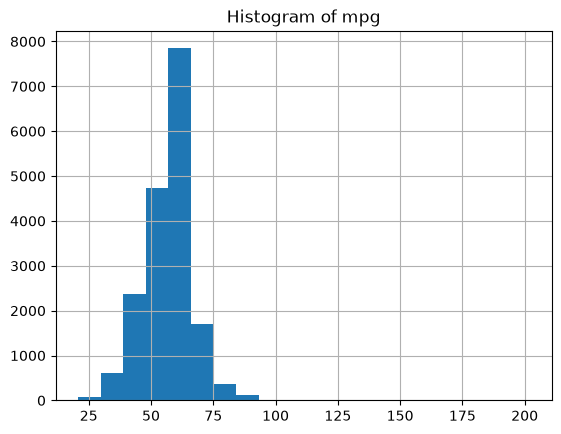

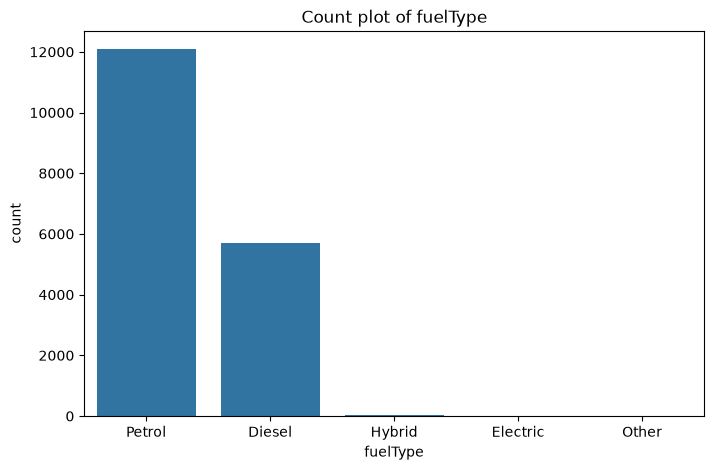

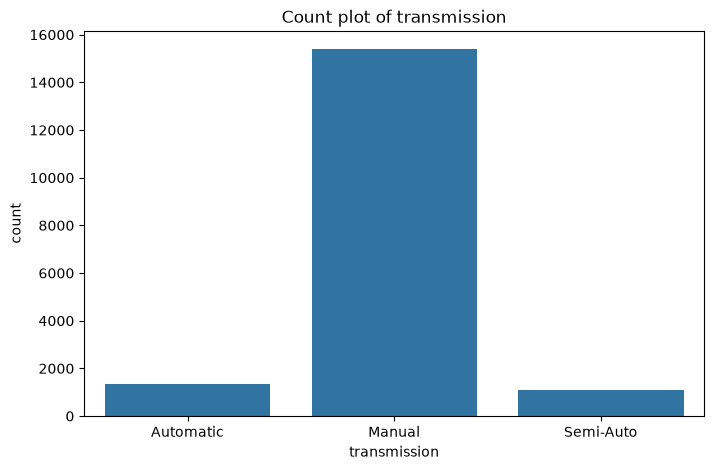

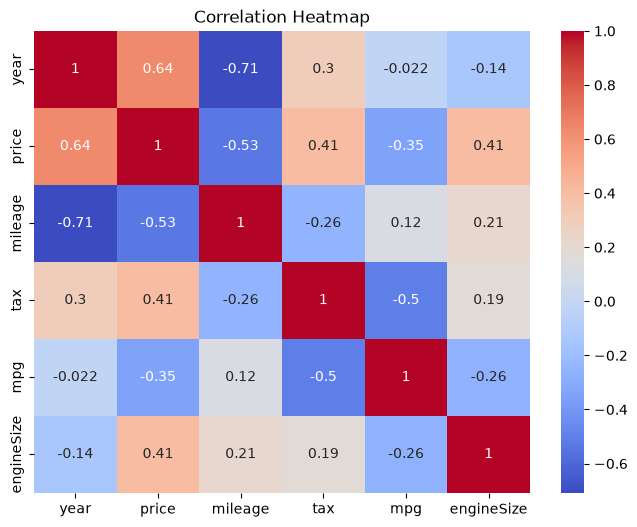

['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize']
price
(17812, 38)
       year   mileage       tax       mpg  engineSize
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561
3  1.041726 -0.665405  0.510777 -1.737858    0.345325
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561


In [36]:
# Q10
pipeline_df = pd.read_csv("ford_car_dataset.csv")

print(pipeline_df.isnull().sum())
print(pipeline_df.duplicated().sum())
pipeline_df = pipeline_df.drop_duplicates()
print(pipeline_df.shape)

for col in ["price", "mileage", "year", "engineSize", "mpg"]:
    plt.figure()
    pipeline_df[col].hist(bins=20)
    plt.title("Histogram of " + col)
    plt.show()

for col in ["fuelType", "transmission"]:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=pipeline_df)
    plt.title("Count plot of " + col)
    plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(pipeline_df[["year","price","mileage","tax","mpg","engineSize"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

pipeline_independent = ["model", "year", "transmission", "mileage", "fuelType", "tax", "mpg", "engineSize"]
pipeline_dependent = "price"

print(pipeline_independent)
print(pipeline_dependent)

pipeline_encoded = pd.get_dummies(pipeline_df, columns=["model", "transmission", "fuelType"])
print(pipeline_encoded.shape)

pipeline_numeric_features = ["year", "mileage", "tax", "mpg", "engineSize"]
pipeline_scaler = StandardScaler()
pipeline_scaled_values = pipeline_scaler.fit_transform(pipeline_encoded[pipeline_numeric_features])
pipeline_scaled_df = pd.DataFrame(pipeline_scaled_values, columns=pipeline_numeric_features)

print(pipeline_scaled_df.head())
